<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Le-pourcentage-d'inertie-associée-à-chaque-dimension" data-toc-modified-id="Le-pourcentage-d'inertie-associée-à-chaque-dimension-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Le pourcentage d'inertie associée à chaque dimension</a></span></li><li><span><a href="#L'influence-des-variables-dans-les-nouvelles-dimensions" data-toc-modified-id="L'influence-des-variables-dans-les-nouvelles-dimensions-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>L'influence des variables dans les nouvelles dimensions</a></span></li><li><span><a href="#Classification-hiérarchique-ascendante" data-toc-modified-id="Classification-hiérarchique-ascendante-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Classification hiérarchique ascendante</a></span><ul class="toc-item"><li><span><a href="#Calcul-des-arbres" data-toc-modified-id="Calcul-des-arbres-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Calcul des arbres</a></span></li><li><span><a href="#Affichage-des-arbres" data-toc-modified-id="Affichage-des-arbres-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Affichage des arbres</a></span></li><li><span><a href="#Prédiction-des-classes" data-toc-modified-id="Prédiction-des-classes-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Prédiction des classes</a></span></li><li><span><a href="#Affichage-des-clusters" data-toc-modified-id="Affichage-des-clusters-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Affichage des clusters</a></span></li></ul></li><li><span><a href="#Clustering-non-hiérarchique" data-toc-modified-id="Clustering-non-hiérarchique-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Clustering non hiérarchique</a></span></li></ul></div>

In [1]:
import pandas as pd               
import seaborn as sns  
import warnings
import os

import matplotlib.font_manager as fm
font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

%pylab inline

plt.style.use('seaborn-darkgrid')
sns.set(font_scale=3)
warnings.filterwarnings(action="ignore")

os.chdir("../donnees")

Populating the interactive namespace from numpy and matplotlib


In [2]:
%%time
temperatures = pd.read_parquet('temperatures.gzip', engine='pyarrow')
temperatures.head()

Wall time: 38.3 ms


,,,,,janv.,févr.,mars,avr.,mai,juin,juill.,août,sept.,oct.,nov.,déc.
Nom,Latitude,Longitude,Altitude,Zone,,,,,,,,,,,,
Abbeville,50.136000,1.834000,69,NO,4.339488,4.961508,7.159573,9.818468,12.974397,15.831397,17.636887,17.744688,15.344691,11.884938,7.807354,5.241632
Ajaccio,41.918000,8.792667,5,SE,8.845452,9.020222,10.923023,13.630346,17.333195,21.449760,23.778255,23.849876,20.827605,17.428642,13.107521,9.916328
Alencon,48.445500,0.110167,143,NO,4.360548,4.935061,7.315260,10.000312,13.440577,16.795848,18.551608,18.346818,15.402646,11.760500,7.611062,5.067731
Bale,47.614333,7.510000,263,NE,1.997963,3.016738,6.601501,10.567396,14.848118,18.719350,20.052836,19.562820,15.413585,10.943476,5.874690,2.970391
Bastia,42.540667,9.485167,10,SE,9.011034,9.158366,11.222681,13.814283,17.732465,22.010528,24.744154,24.773452,21.194754,17.341999,13.156176,10.097650


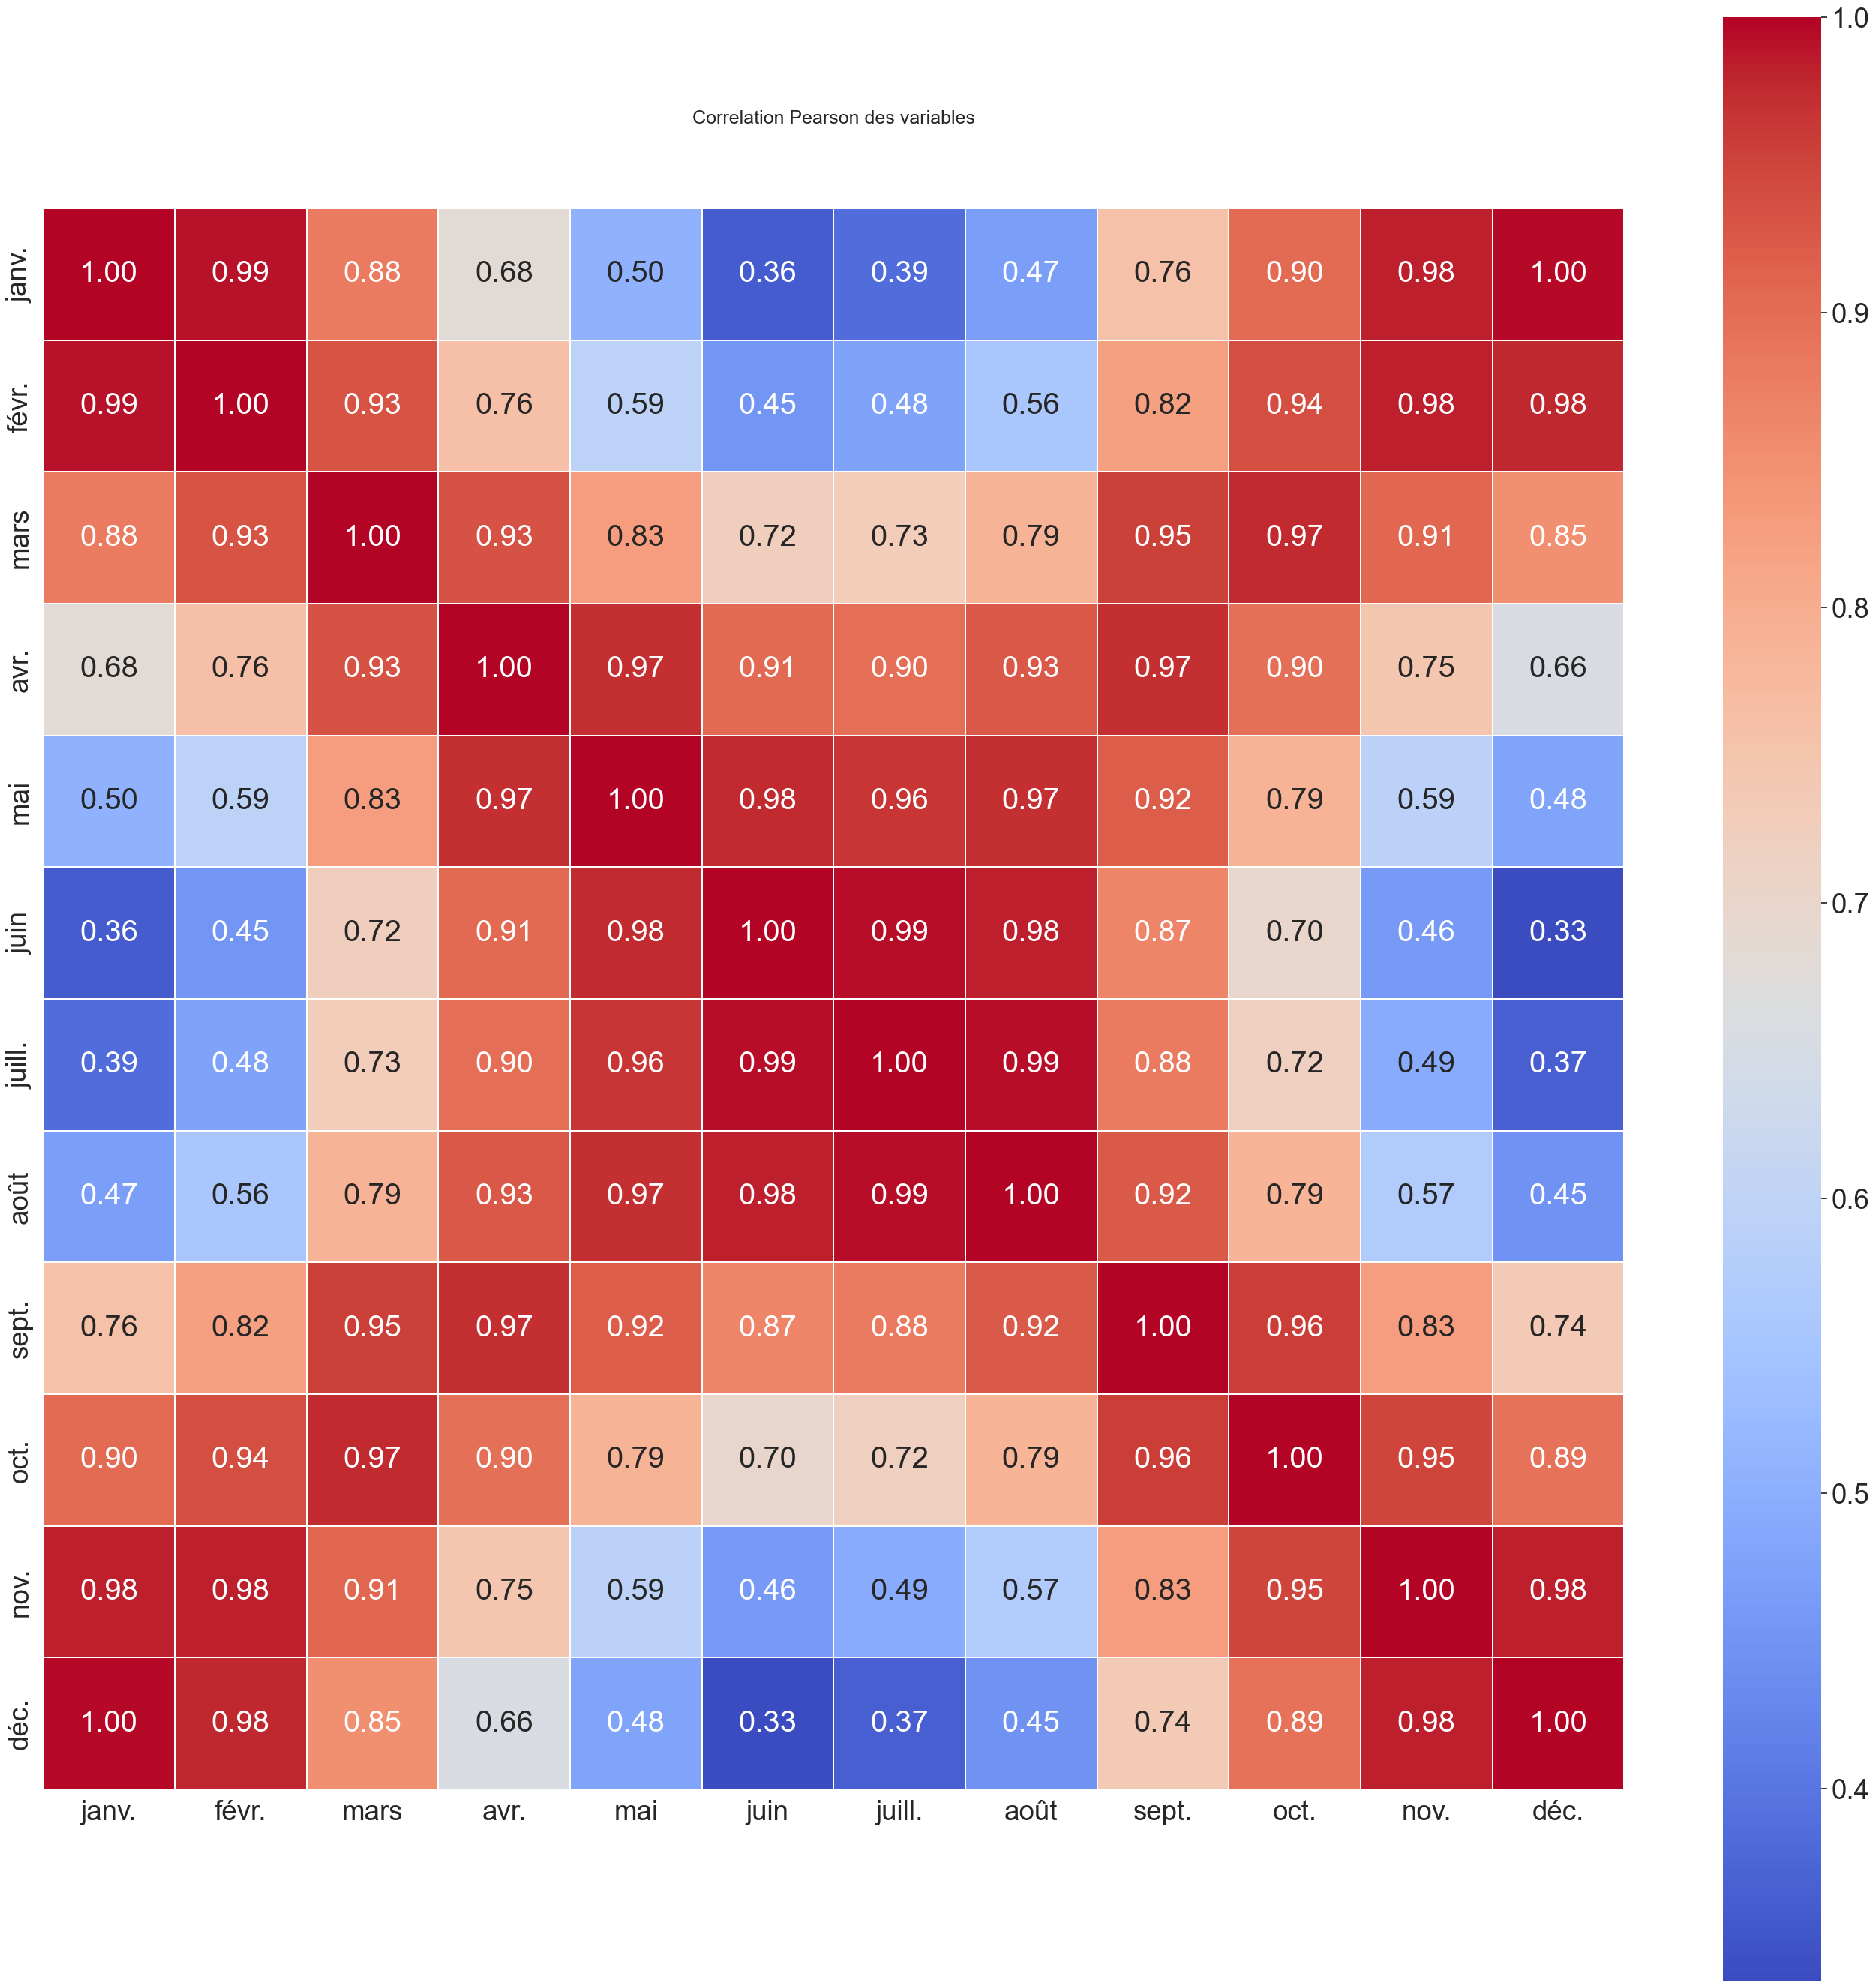

In [3]:
plt.figure(figsize=(34,34))
sns.set(font_scale=2.4)
plt.title('Correlation Pearson des variables', y=1.05, size=18)
sns.heatmap(temperatures.corr(),linewidths=0.3,vmax=1.0, fmt= '.2f', 
            square=True, cmap='coolwarm', linecolor='white', annot=True)
sns.set(font_scale=2)

In [4]:
x = temperatures
from sklearn.preprocessing import StandardScaler,MinMaxScaler
modelStd = StandardScaler()
modelStd.fit(x)
x = modelStd.transform(x)

In [5]:
modelMinMax = MinMaxScaler()
modelMinMax.fit(x)
xmin = modelMinMax.transform(x)
pd.DataFrame(xmin).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.423068,0.433613,0.345626,0.319413,0.198113,0.139165,0.113357,0.133486,0.247426,0.281954,0.362881,0.409549
1,0.979551,0.952849,0.874931,0.893343,0.837175,0.825131,0.834391,0.886140,0.929230,1.000000,0.994204,0.977953
2,0.425669,0.430229,0.367522,0.346792,0.266461,0.256918,0.220751,0.207717,0.254633,0.265836,0.339500,0.388404
3,0.133892,0.184816,0.267136,0.432174,0.472827,0.491766,0.397004,0.357627,0.255993,0.160012,0.132674,0.133385
4,1.000000,0.970522,0.917076,0.921037,0.895714,0.893598,0.947794,1.000000,0.974885,0.988778,1.000000,1.000000


In [6]:
m = temperatures.mean(axis=0)
s = temperatures.std(axis=0)
X = (temperatures - m)/s
X.head()

,,,,,janv.,févr.,mars,avr.,mai,juin,juill.,août,sept.,oct.,nov.,déc.
Nom,Latitude,Longitude,Altitude,Zone,,,,,,,,,,,,
Abbeville,50.136000,1.834000,69,NO,-0.402850,-0.470028,-0.836212,-0.981111,-1.089313,-1.264283,-1.188230,-1.109141,-0.921331,-0.751445,-0.456246,-0.387122
Ajaccio,41.918000,8.792667,5,SE,1.615428,1.574056,1.373008,1.431647,1.406339,1.362684,1.441472,1.563684,1.806091,1.949668,1.937547,1.711188
Alencon,48.445500,0.110167,143,NO,-0.393417,-0.483347,-0.744820,-0.866012,-0.822399,-0.813337,-0.796551,-0.845531,-0.892502,-0.812076,-0.544901,-0.465180
Bale,47.614333,7.510000,263,NE,-1.451649,-1.449470,-1.163812,-0.507072,-0.016504,0.086031,-0.153733,-0.313171,-0.887060,-1.210163,-1.329124,-1.406604
Bastia,42.540667,9.485167,10,SE,1.689594,1.643629,1.548913,1.548070,1.634944,1.624881,1.855065,1.968022,1.988725,1.907452,1.959522,1.792577


In [7]:
pd.DataFrame(x, index=temperatures.index, columns=temperatures.columns)

,,,,,janv.,févr.,mars,avr.,mai,juin,juill.,août,sept.,oct.,nov.,déc.
Nom,Latitude,Longitude,Altitude,Zone,,,,,,,,,,,,
Abbeville,50.136000,1.834000,69,NO,-0.407734,-0.475726,-0.846348,-0.993004,-1.102517,-1.279608,-1.202633,-1.122586,-0.932499,-0.760554,-0.461777,-0.391815
Ajaccio,41.918000,8.792667,5,SE,1.635010,1.593136,1.389651,1.449000,1.423386,1.379202,1.458945,1.582638,1.827983,1.973301,1.961033,1.731930
Alencon,48.445500,0.110167,143,NO,-0.398186,-0.489206,-0.753849,-0.876509,-0.832368,-0.823196,-0.806207,-0.855781,-0.903321,-0.821920,-0.551506,-0.470819
Bale,47.614333,7.510000,263,NE,-1.469245,-1.467040,-1.177919,-0.513218,-0.016704,0.087074,-0.155596,-0.316967,-0.897813,-1.224832,-1.345236,-1.423654
Bastia,42.540667,9.485167,10,SE,1.710075,1.663552,1.567688,1.566836,1.654762,1.644577,1.877551,1.991877,2.012832,1.930573,1.983275,1.814306
Belle Ile,47.294333,-3.218333,34,NO,1.315417,1.067915,0.432219,-0.095997,-0.556558,-0.925984,-0.953563,-0.876210,-0.097664,0.566027,1.246917,1.484922
Bordeaux,44.830667,-0.691333,47,SO,0.624185,0.767943,1.025379,0.996127,0.834019,0.578935,0.412762,0.504602,0.738333,0.650080,0.458627,0.502746
Bourges,47.059167,2.359833,161,NO,-0.502848,-0.495228,-0.262657,-0.119960,-0.017077,0.102215,0.047598,0.029568,-0.233178,-0.439721,-0.545650,-0.546305
Brest,48.444167,-4.412000,94,NO,0.790867,0.605625,-0.141141,-0.935761,-1.297869,-1.596446,-1.593086,-1.602366,-0.980729,-0.336779,0.429882,0.783707


In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=12)

In [9]:
from sklearn.decomposition import PCA
pca = PCA()

In [10]:
model = pca.fit(x)

# Le pourcentage d'inertie associée à chaque dimension

In [11]:
pca.explained_variance_ratio_

array([8.04243857e-01, 1.82543165e-01, 7.66310425e-03, 3.03790601e-03,
       1.24916590e-03, 3.89653241e-04, 3.80461064e-04, 2.25130725e-04,
       1.13144640e-04, 8.00279045e-05, 4.66514999e-05, 2.77331853e-05])

In [12]:
pca.explained_variance_ratio_.cumsum()*100

array([ 80.42438565,  98.67870216,  99.44501258,  99.74880318,
        99.87371977,  99.9126851 ,  99.9507312 ,  99.97324428,
        99.98455874,  99.99256153,  99.99722668, 100.        ])

In [13]:
sum(pca.explained_variance_ratio_.cumsum()*100 <= 95) + 1

2

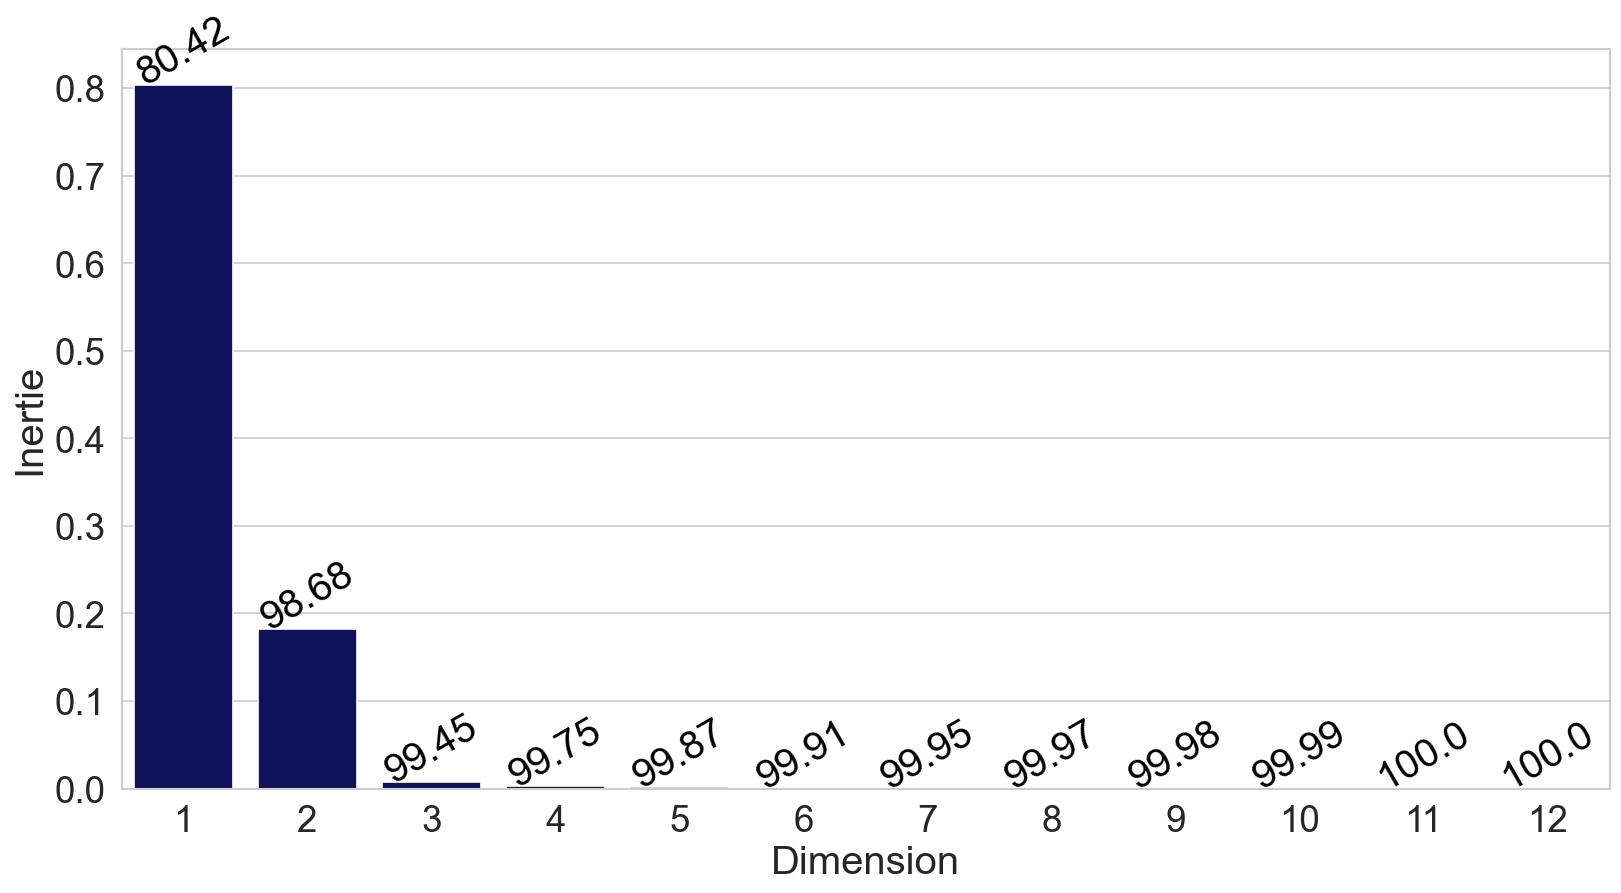

In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font1 = fm.FontProperties(size=24)

inertie = pd.DataFrame(pca.explained_variance_ratio_,columns=['Inertie']) 
inertie['label'] = np.round(pca.explained_variance_ratio_.cumsum()*100,2)
inertie['Dimension'] = range(1,len(pca.explained_variance_)+1)

plt.figure(figsize=(16,8),dpi=120)
sns.set_style("whitegrid")
g = sns.barplot(x="Dimension",y='Inertie', data=inertie, color="#030764")

for index, row in inertie.iterrows():
    g.text(row.name,row.Inertie, row.label, color='black', ha="center", rotation=30)
    
plt.xlabel('Dimension', fontproperties=font1)
plt.ylabel('Inertie', fontproperties=font1)

plt.show()

plt.style.use('seaborn-darkgrid')
sns.set(font_scale=2)

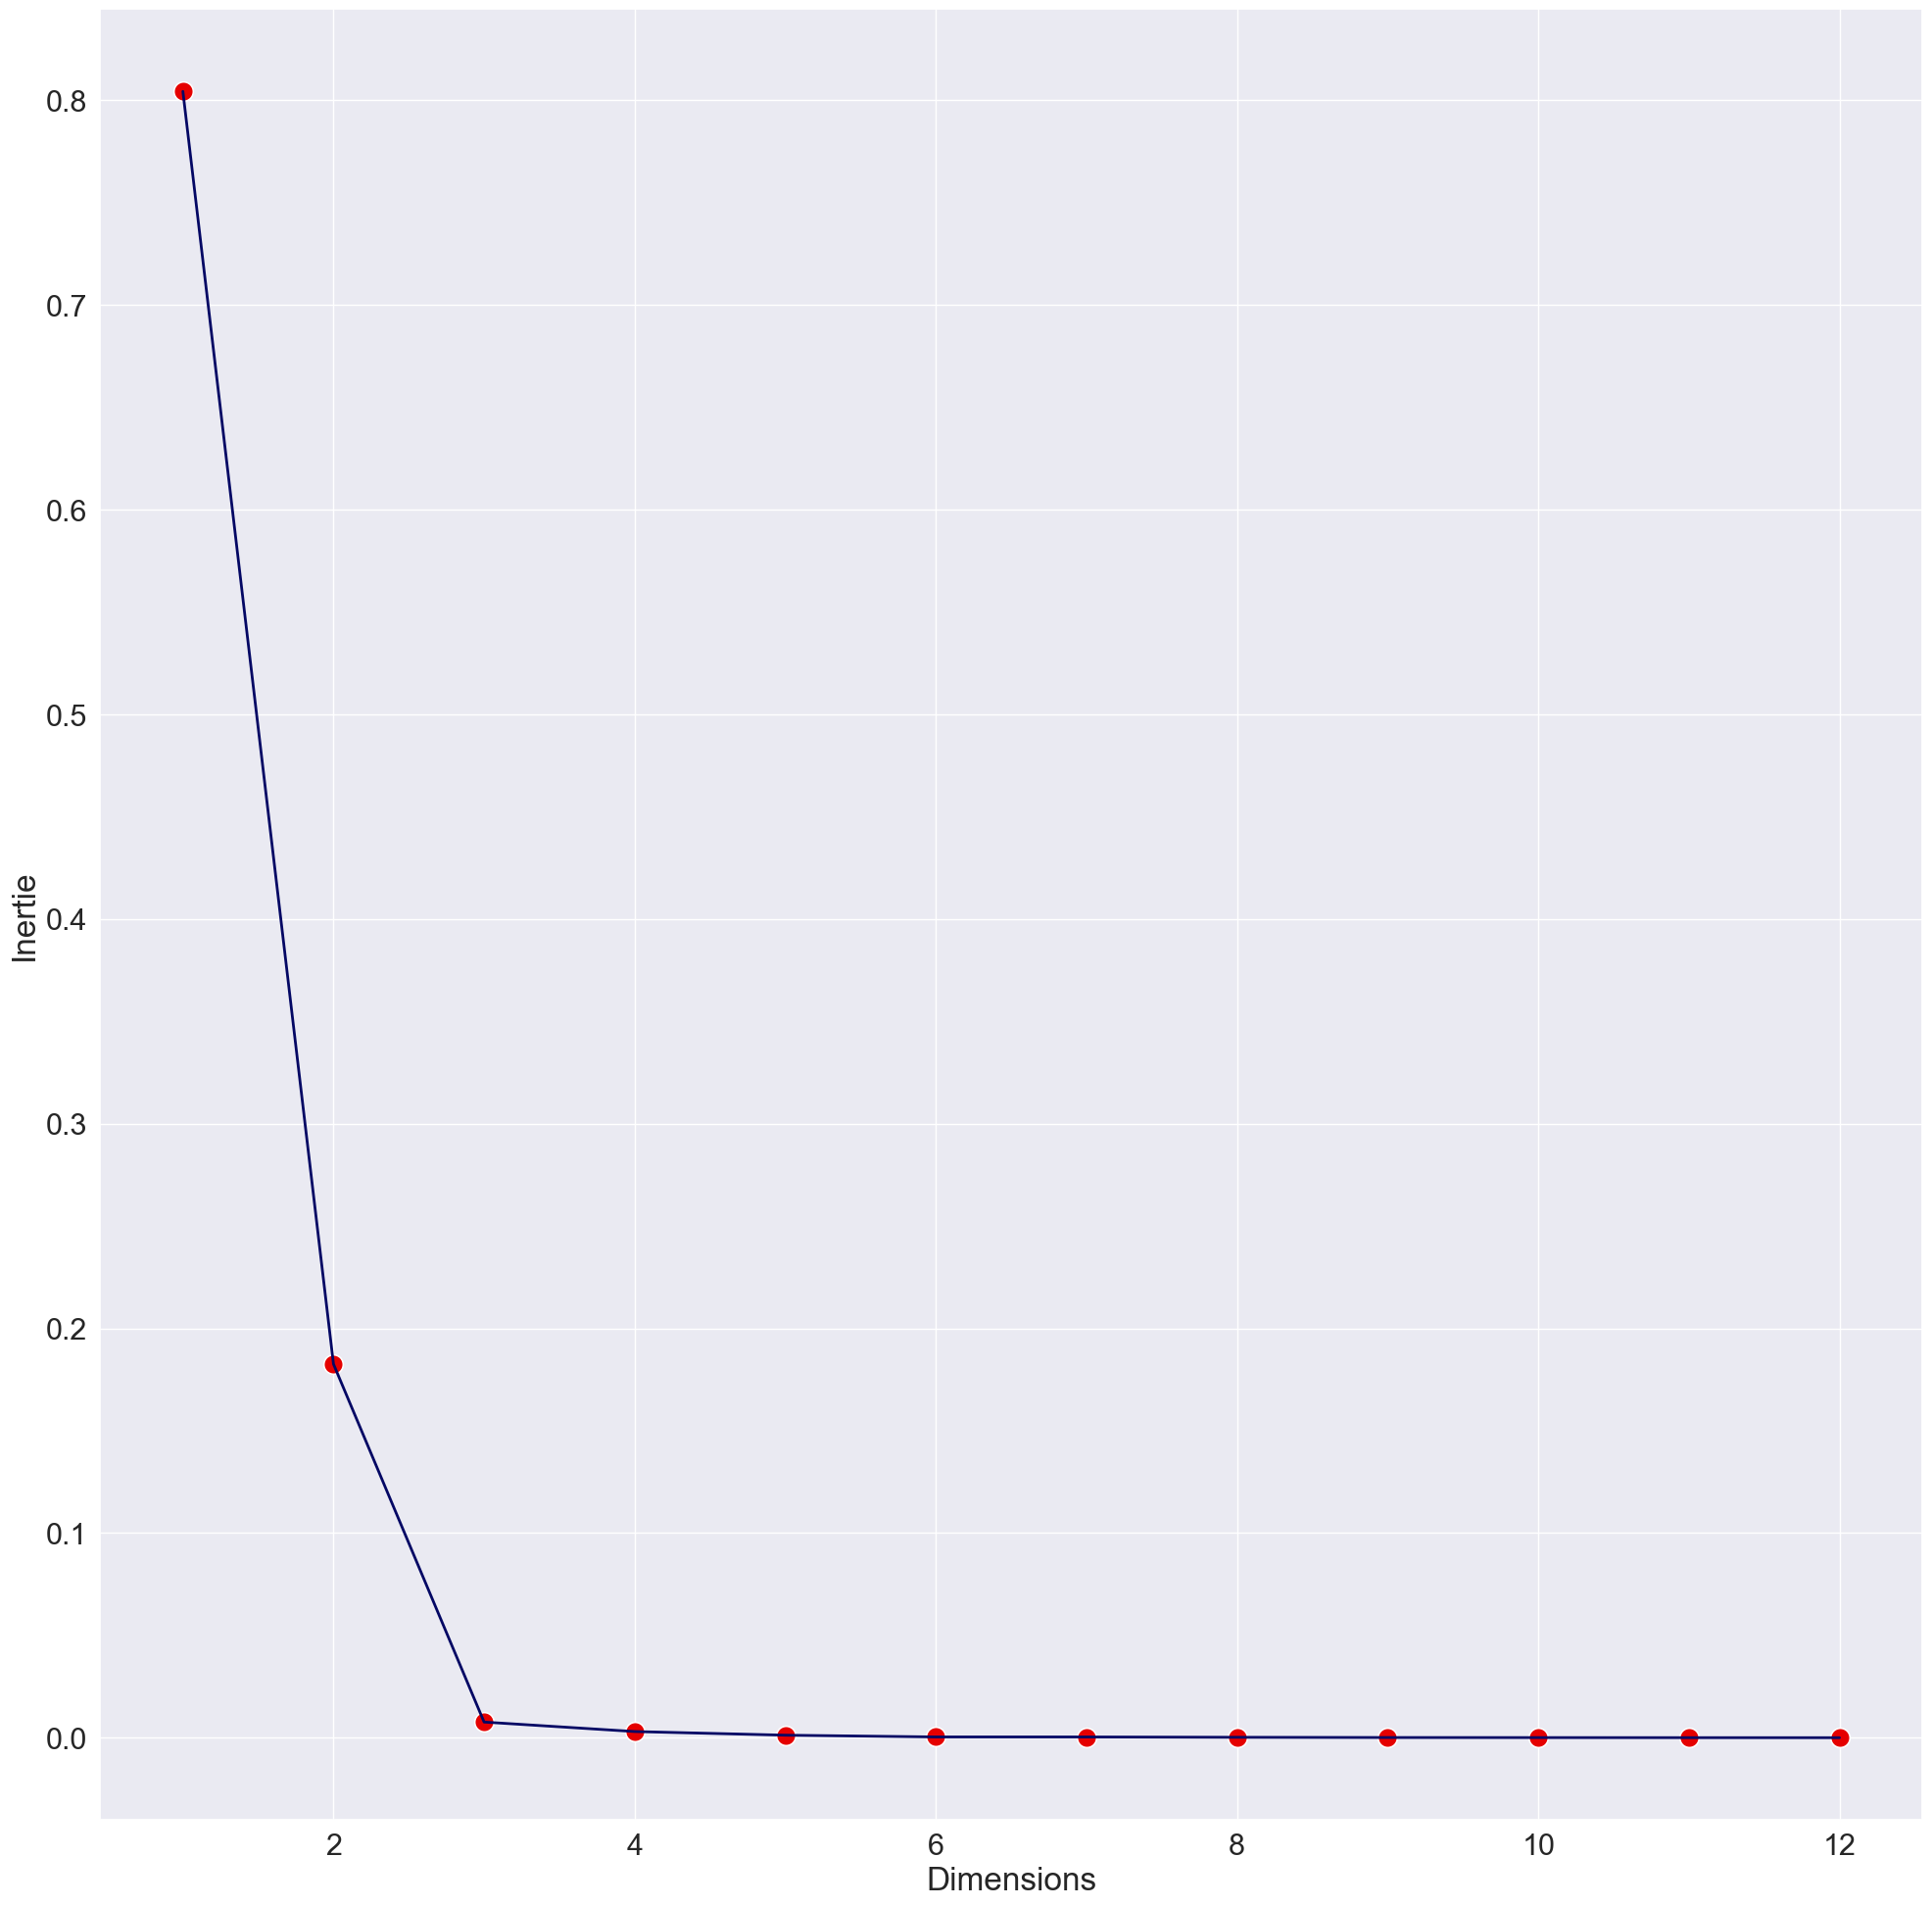

In [15]:
fig, ax = plt.subplots(figsize=(24,24));
graph = sns.lineplot( x='Dimension',
                      y='Inertie',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764");
sns.scatterplot(x     = 'Dimension',
                y     = 'Inertie',
                data  = inertie,
                s     = 200,
                ci    = None, 
                color = "#e50000",
                ax    = graph);

ax.set_xlabel('Dimensions');
ax.set_ylabel('Inertie');

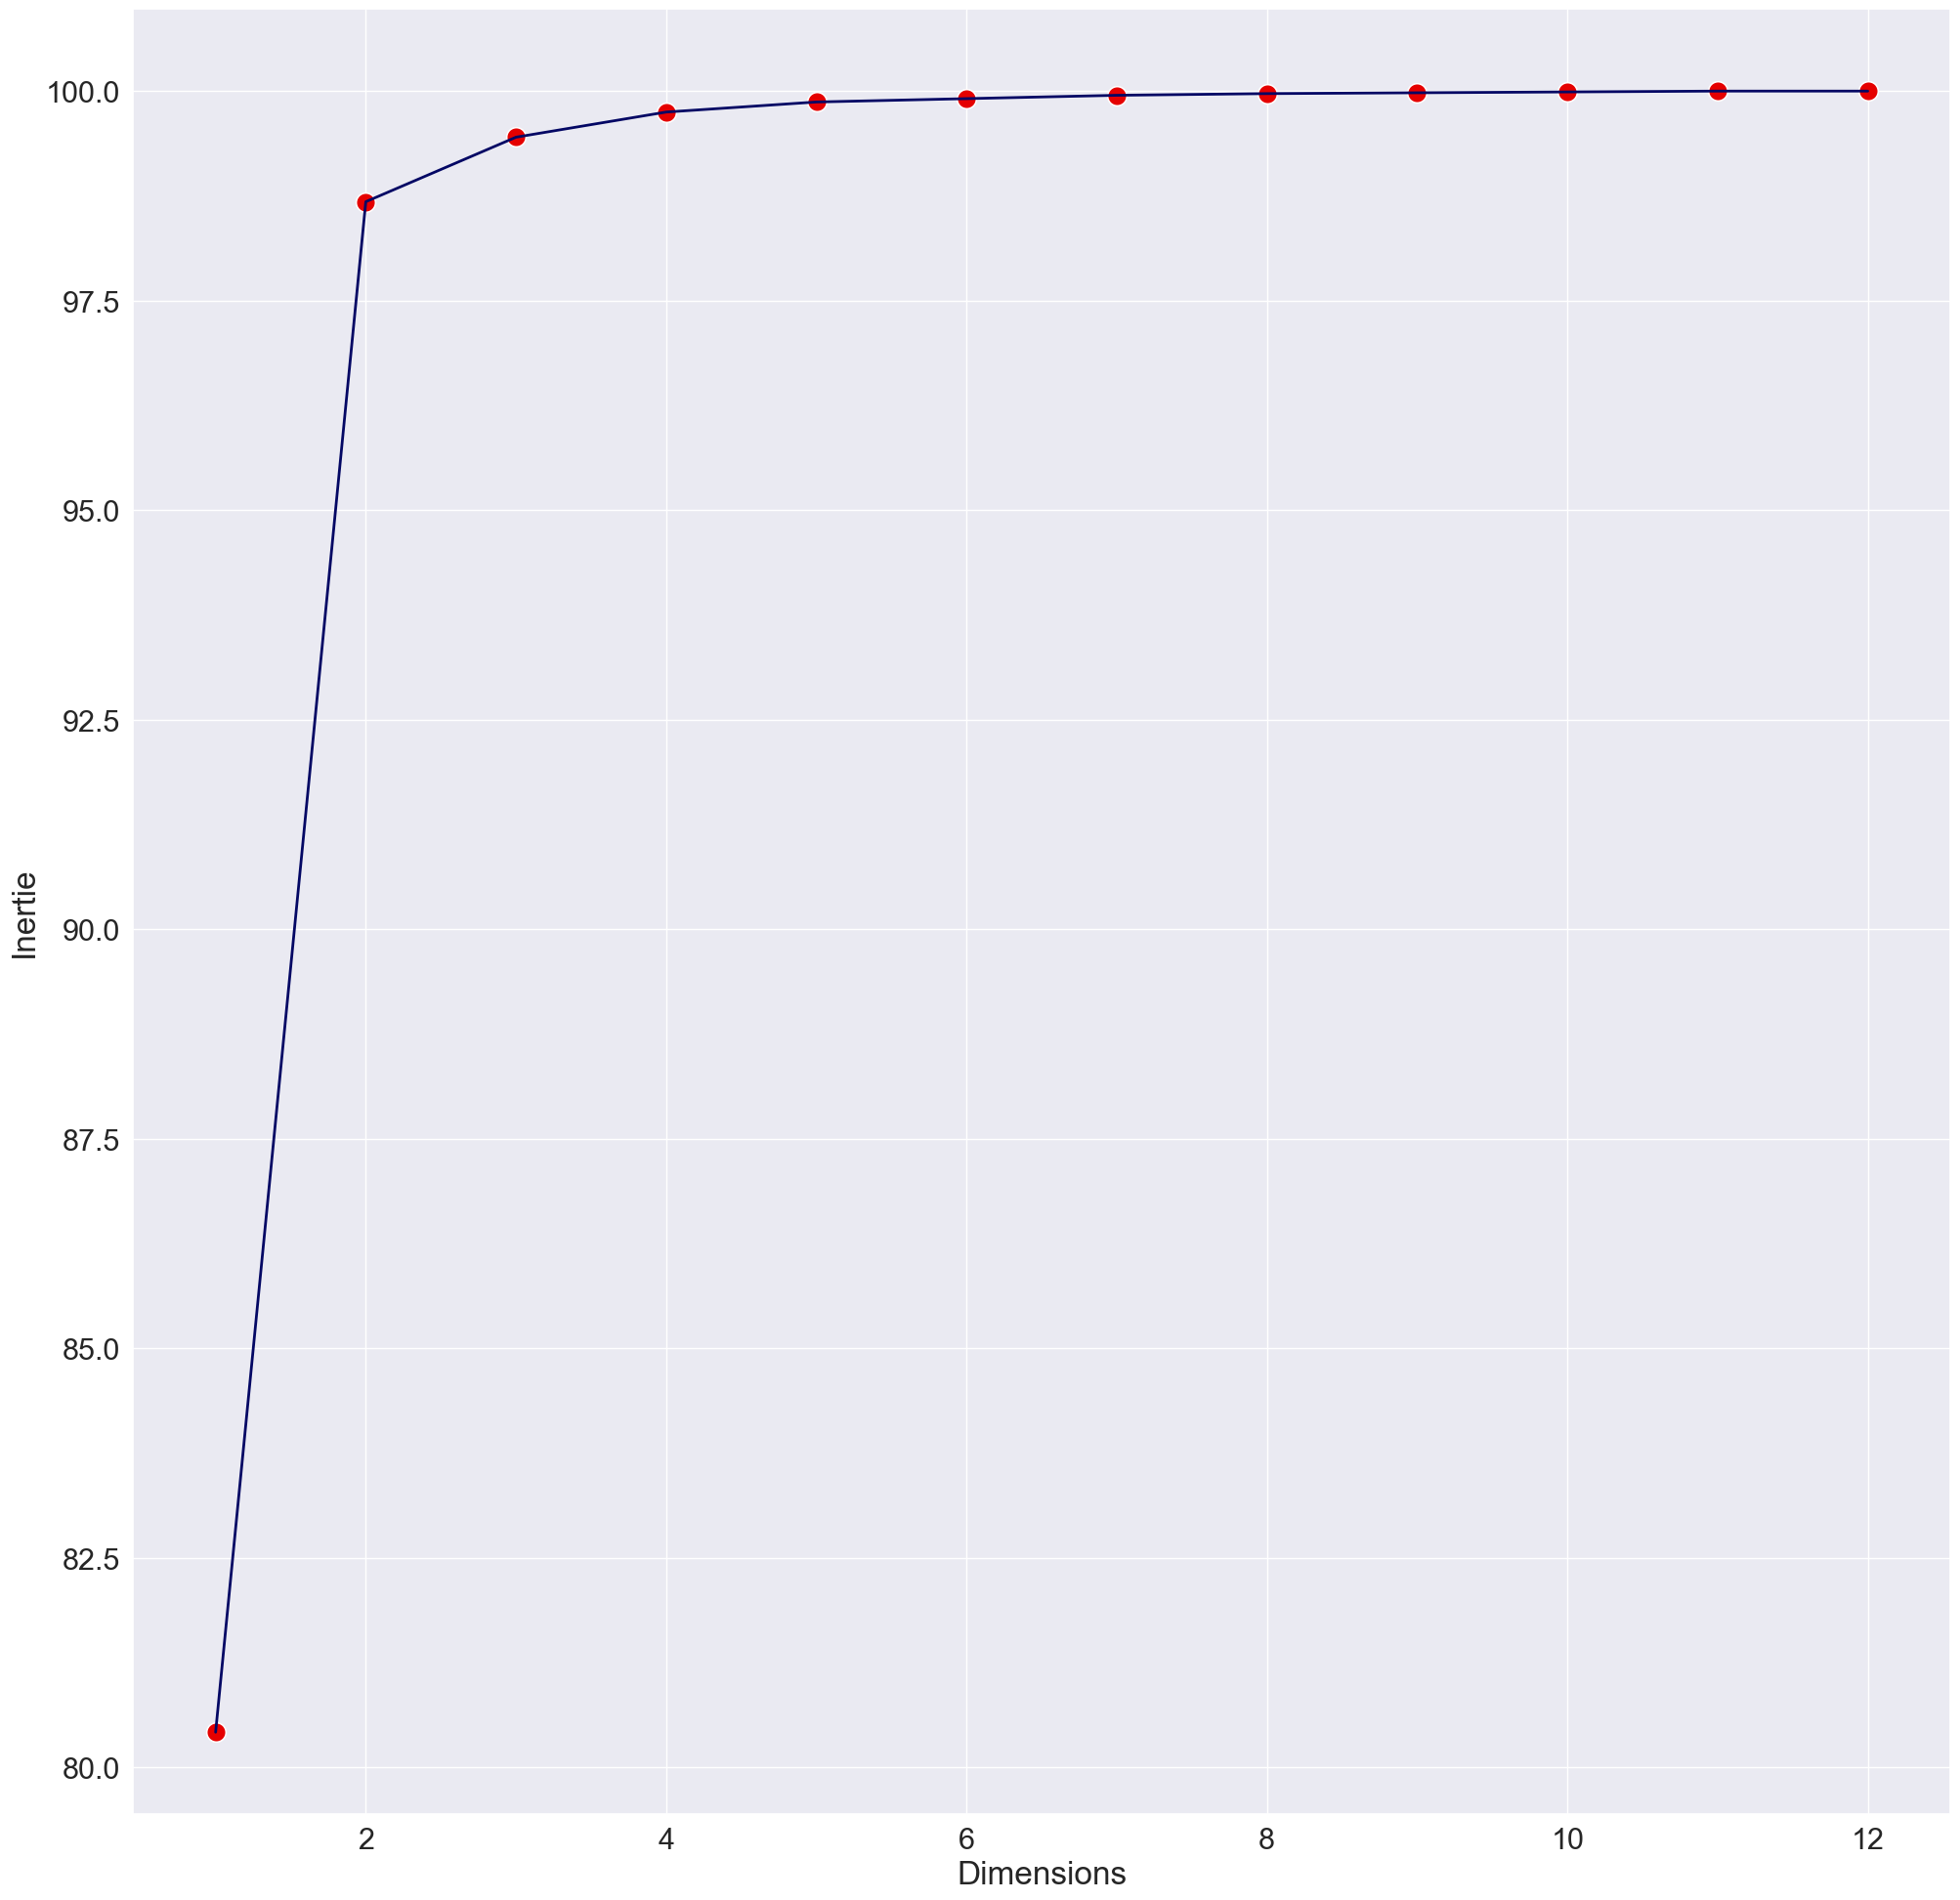

In [16]:
fig, ax = plt.subplots(figsize=(24,24));
graph = sns.lineplot( x='Dimension',
                      y='label',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764");
sns.scatterplot(x     = 'Dimension',
                y     = 'label',
                data  = inertie,
                s     = 200,
                ci    = None, 
                color = "#e50000",
                ax    = graph);

ax.set_xlabel('Dimensions');
ax.set_ylabel('Inertie');

# L'influence des variables dans les nouvelles dimensions

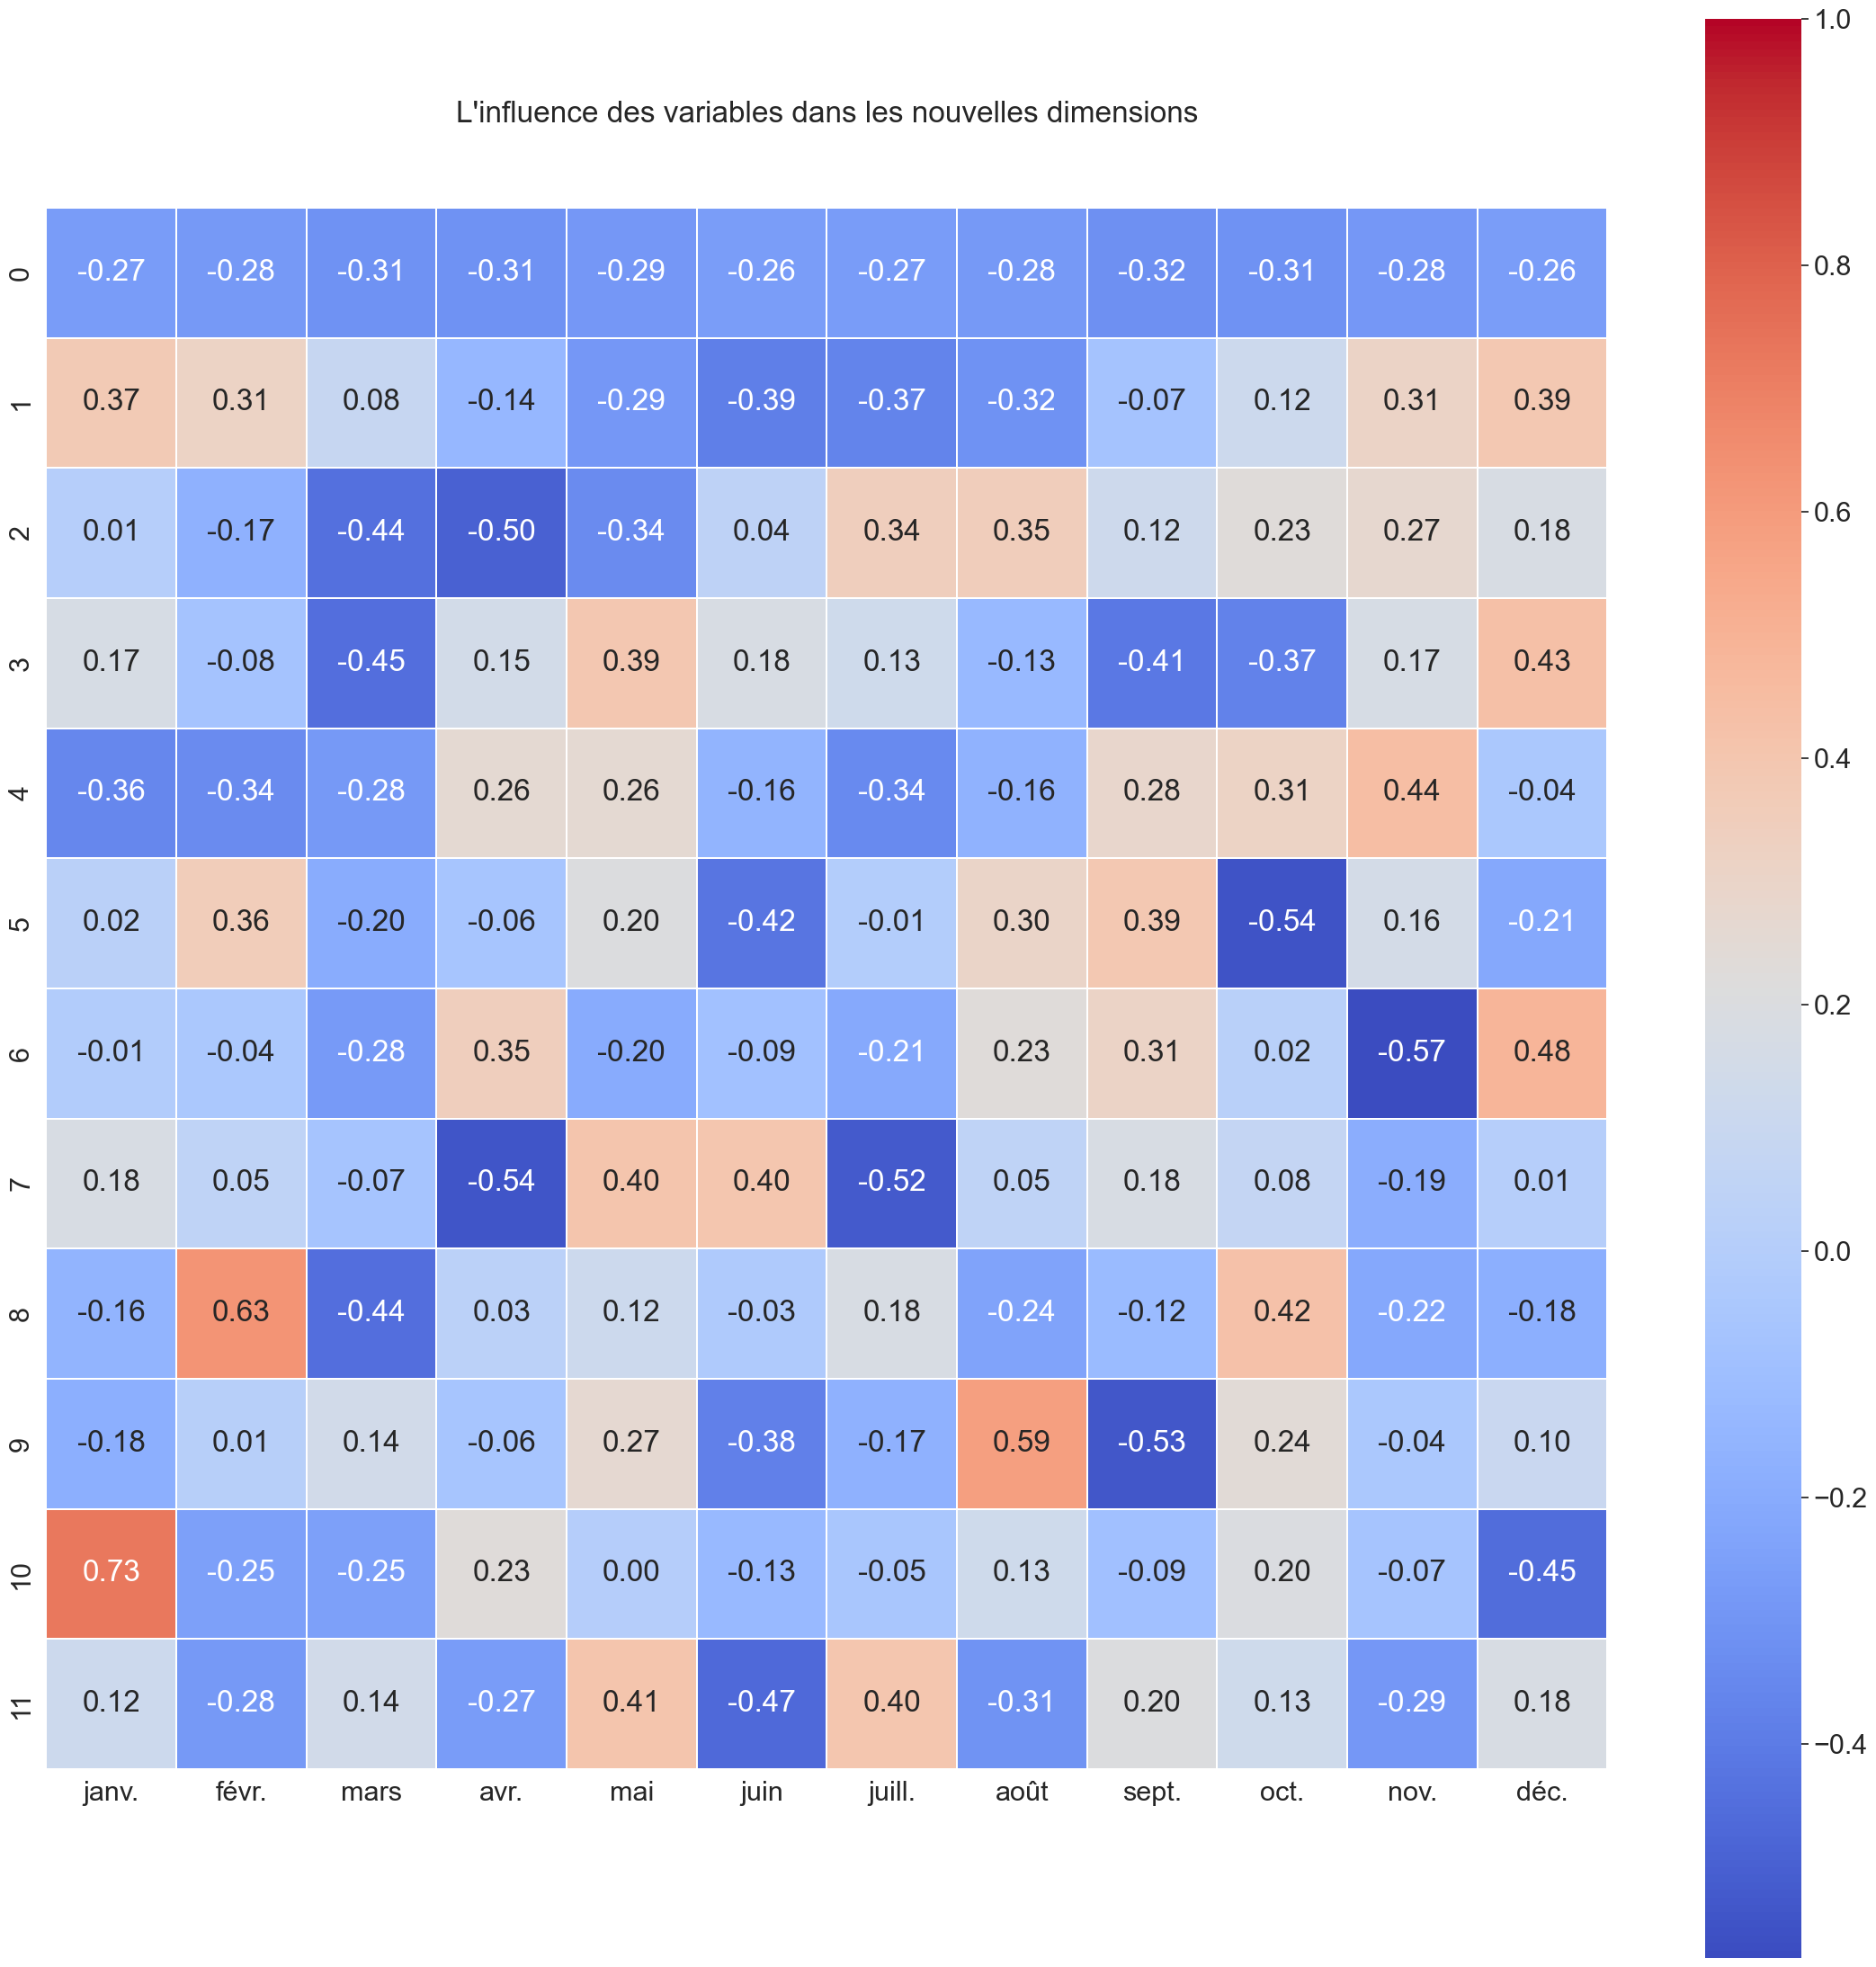

In [17]:
plt.figure(figsize=(28,28))
sns.set(font_scale=2)
plt.title("L'influence des variables dans les nouvelles dimensions", y=1.05, size=24)
sns.heatmap(pd.DataFrame(pca.components_, columns=X.columns),
            fmt= '.2f',linewidths=0.3,vmax=1.0, 
            square=True, cmap='coolwarm', linecolor='white', annot=True);

In [18]:
n_components = sum(pca.explained_variance_ratio_.cumsum() < .95 ) + 1 
from sklearn.decomposition import PCA
modelPCA = PCA(n_components=n_components)
x_proj = modelPCA.fit_transform(x)
donnees2d = pd.DataFrame(x_proj, index=temperatures.index, columns=[f'Dim{i+1:02d}' for i in range(n_components)])

In [19]:
n_components=3
modelPCA = PCA(n_components=n_components)
x_proj = modelPCA.fit_transform(x)
donnees3d = pd.DataFrame(x_proj, index=temperatures.index, columns=[f'Dim{i+1:02d}' for i in range(n_components)])

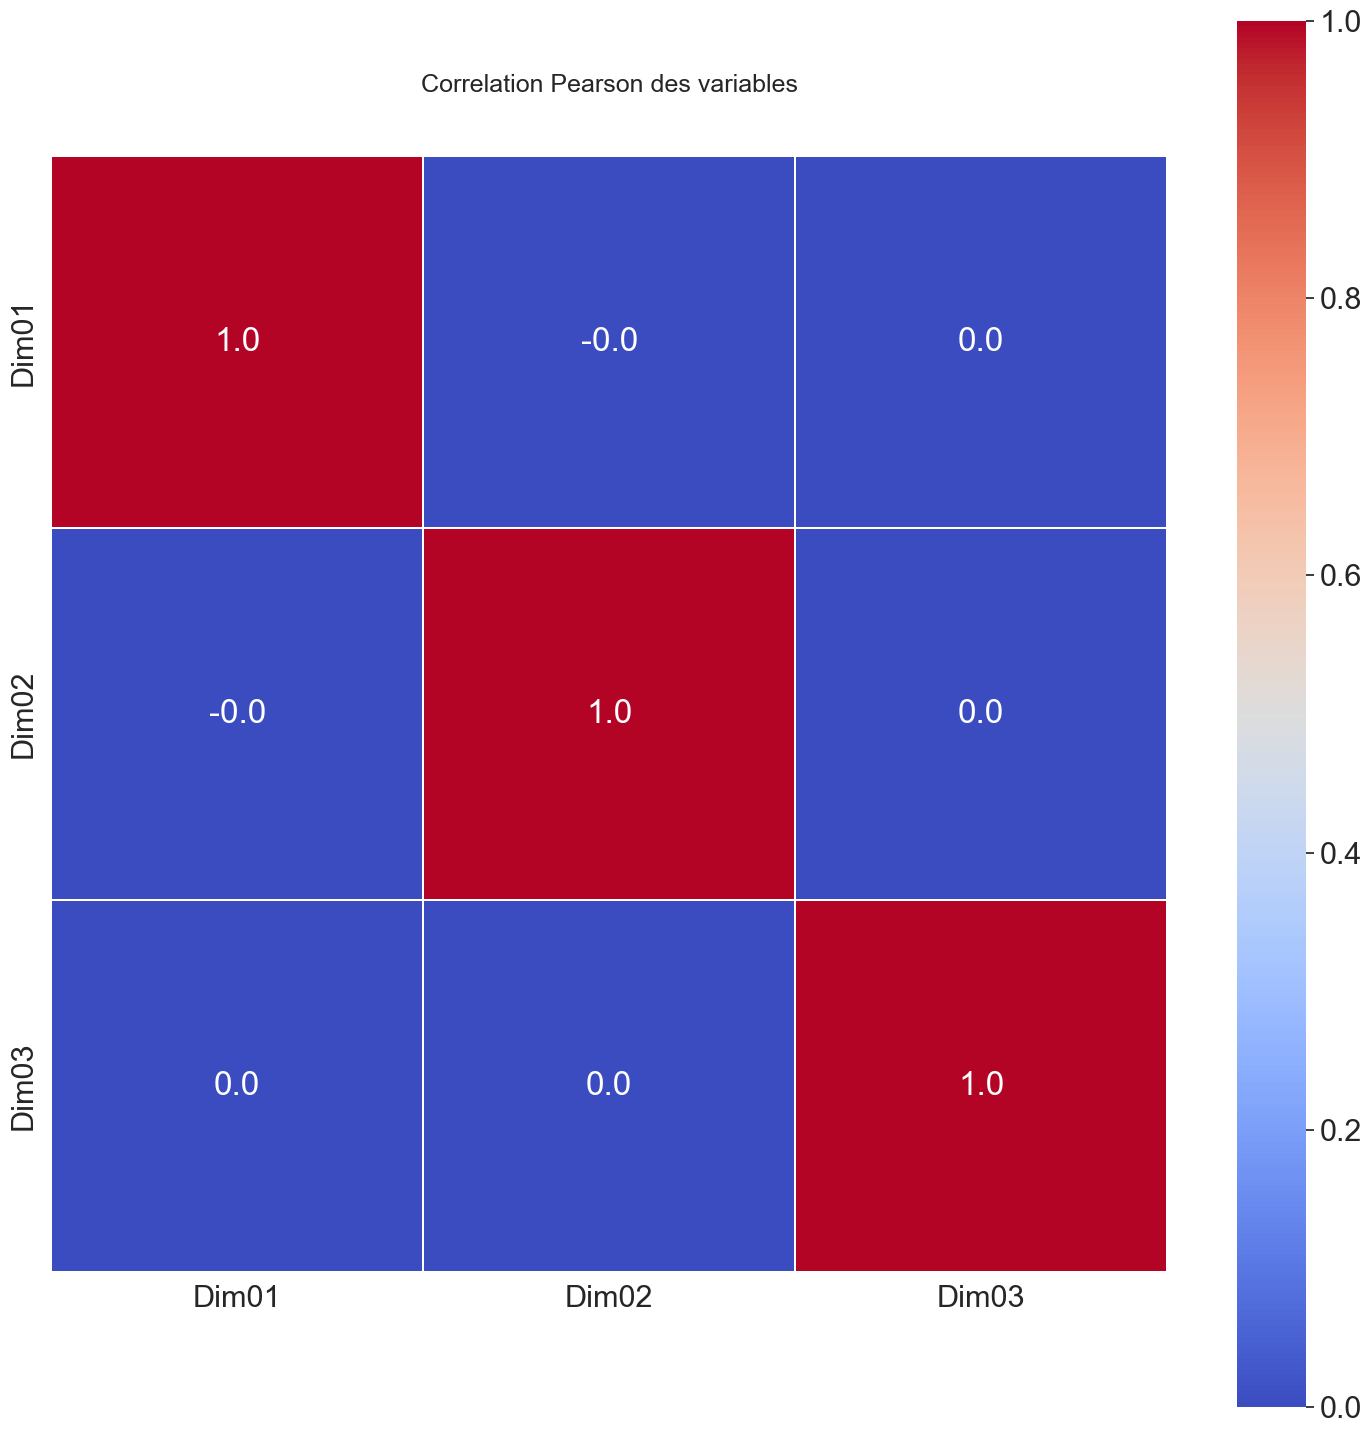

In [20]:
plt.figure(figsize=(18,18))
plt.title('Correlation Pearson des variables', y=1.05, size=18)
sns.heatmap(donnees3d.corr(),linewidths=0.3,vmax=1.0, fmt= '.1f', 
            square=True, cmap='coolwarm', linecolor='white', annot=True);

In [21]:
donnees3d.head()

,,,,,Dim01,Dim02,Dim03
Nom,Latitude,Longitude,Altitude,Zone,,,
Abbeville,50.136000,1.834000,69,NO,2.879743,1.071171,-0.024267
Ajaccio,41.918000,8.792667,5,SE,-5.598592,0.401231,0.559796
Alencon,48.445500,0.110167,143,NO,2.493413,0.507866,-0.013326
Bale,47.614333,7.510000,263,NE,2.879361,-1.947294,-0.157333
Bastia,42.540667,9.485167,10,SE,-6.167923,0.015735,0.663955


In [22]:
import plotly.express as px
import plotly.graph_objs as go

layout = go.Layout({"showlegend": False})

fig = px.scatter_3d(donnees3d.reset_index(), 
                    x='Dim01', 
                    y='Dim02', 
                    z='Dim03',
                    color='Zone',
#                     size=100+donnees3d.reset_index().Altitude,
#                     symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [23]:
import plotly.express as px
import plotly.graph_objs as go

fig = px.scatter(donnees2d.reset_index(), 
                    x='Dim01', 
                    y='Dim02', 
#                     z='Dim03',
                    color='Zone',
#                     size=100+donnees3d.reset_index().Altitude,
#                     symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=996,
                    height=512,
                   )

fig.show()

# Classification hiérarchique ascendante

In [24]:
Villes = donnees2d.reset_index().Nom.values
donnees2d.head()

,,,,,Dim01,Dim02
Nom,Latitude,Longitude,Altitude,Zone,,
Abbeville,50.136000,1.834000,69,NO,2.879743,1.071171
Ajaccio,41.918000,8.792667,5,SE,-5.598592,0.401231
Alencon,48.445500,0.110167,143,NO,2.493413,0.507866
Bale,47.614333,7.510000,263,NE,2.879361,-1.947294
Bastia,42.540667,9.485167,10,SE,-6.167923,0.015735


## Calcul des arbres 

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(donnees2d, 'ward')

## Affichage des arbres

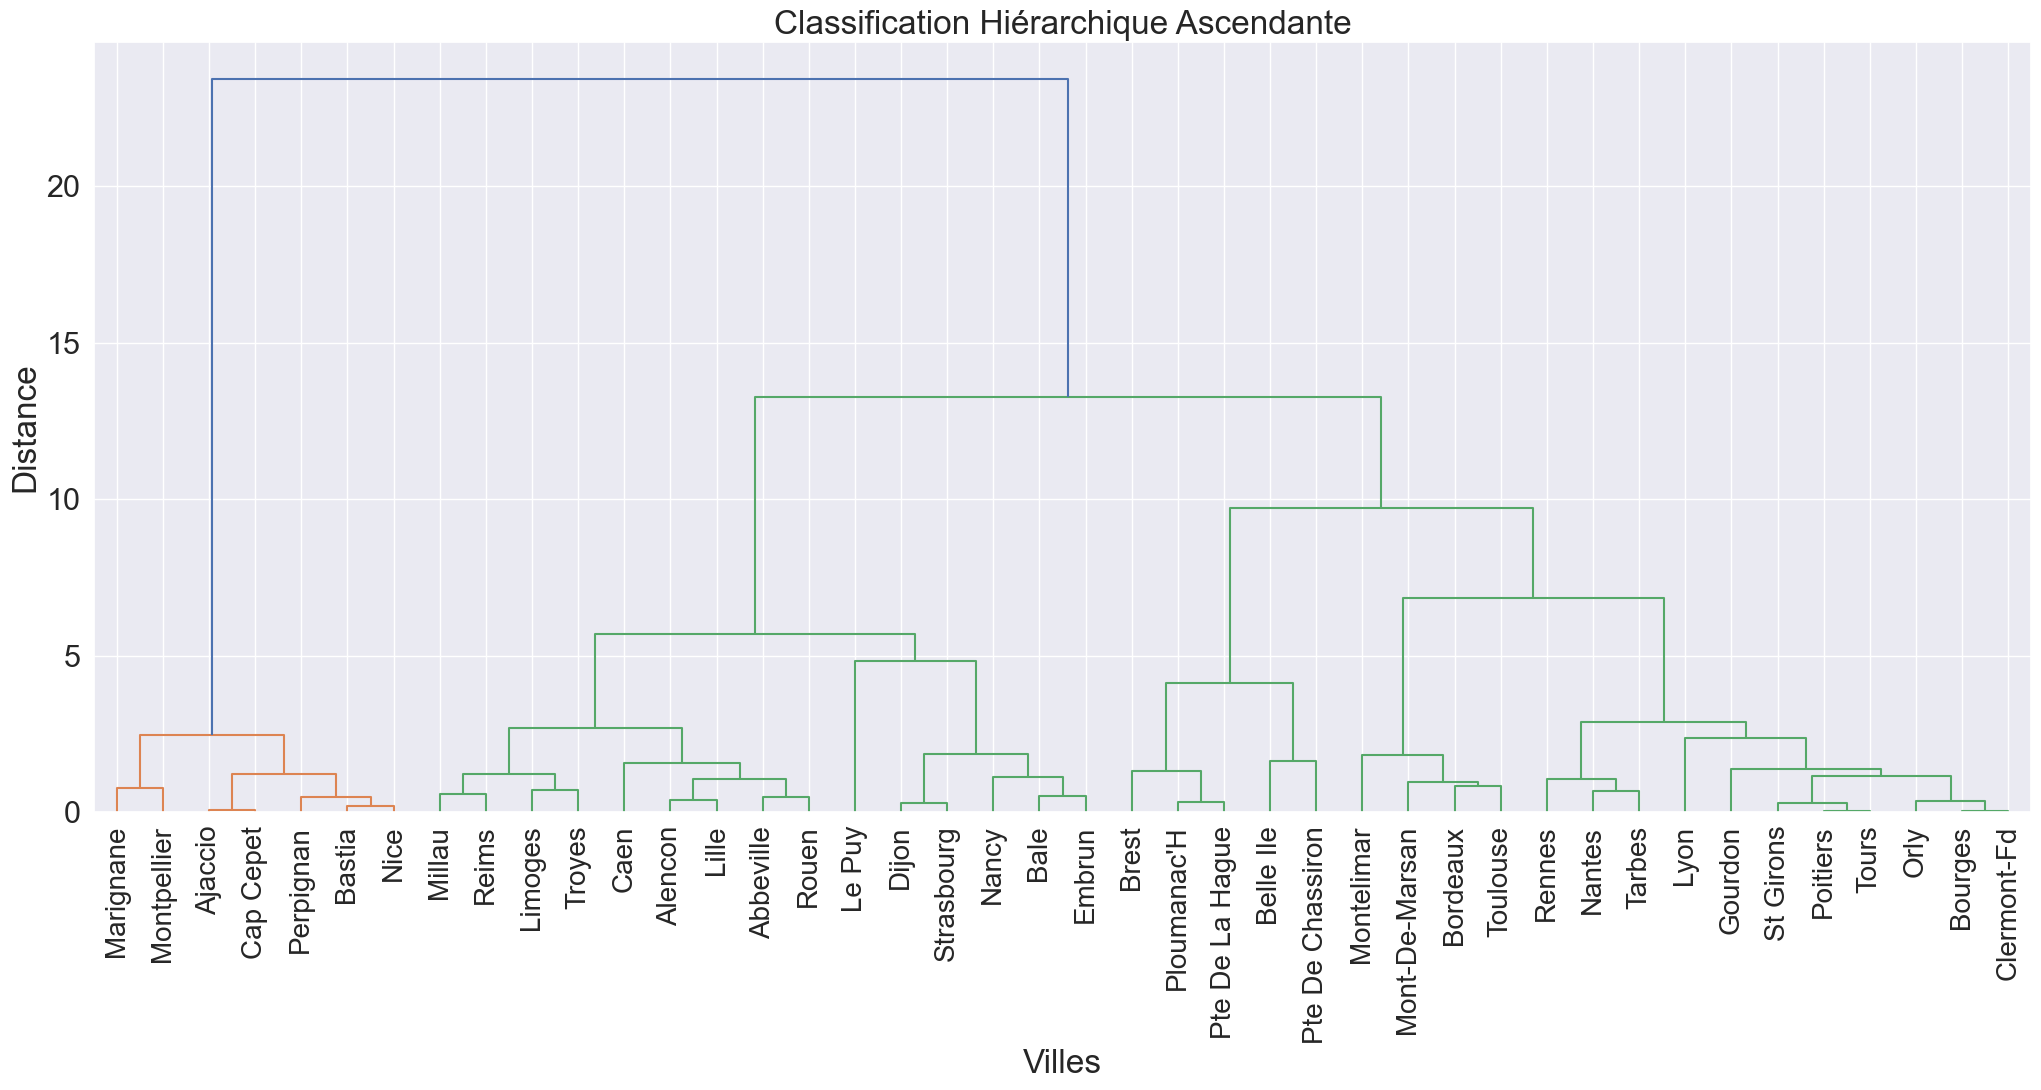

In [26]:
plt.figure(figsize=(25, 10))
plt.title('Classification Hiérarchique Ascendante')
plt.xlabel('Villes')
plt.ylabel('Distance')
dendrogram( Z,leaf_rotation=90.,leaf_font_size=20.,
           labels = Villes)
plt.show()

In [27]:
def afficheDendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Classification Hiérarchique Ascendante')
        plt.xlabel('Villes ou (taille du cluster)')
        plt.ylabel('Distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

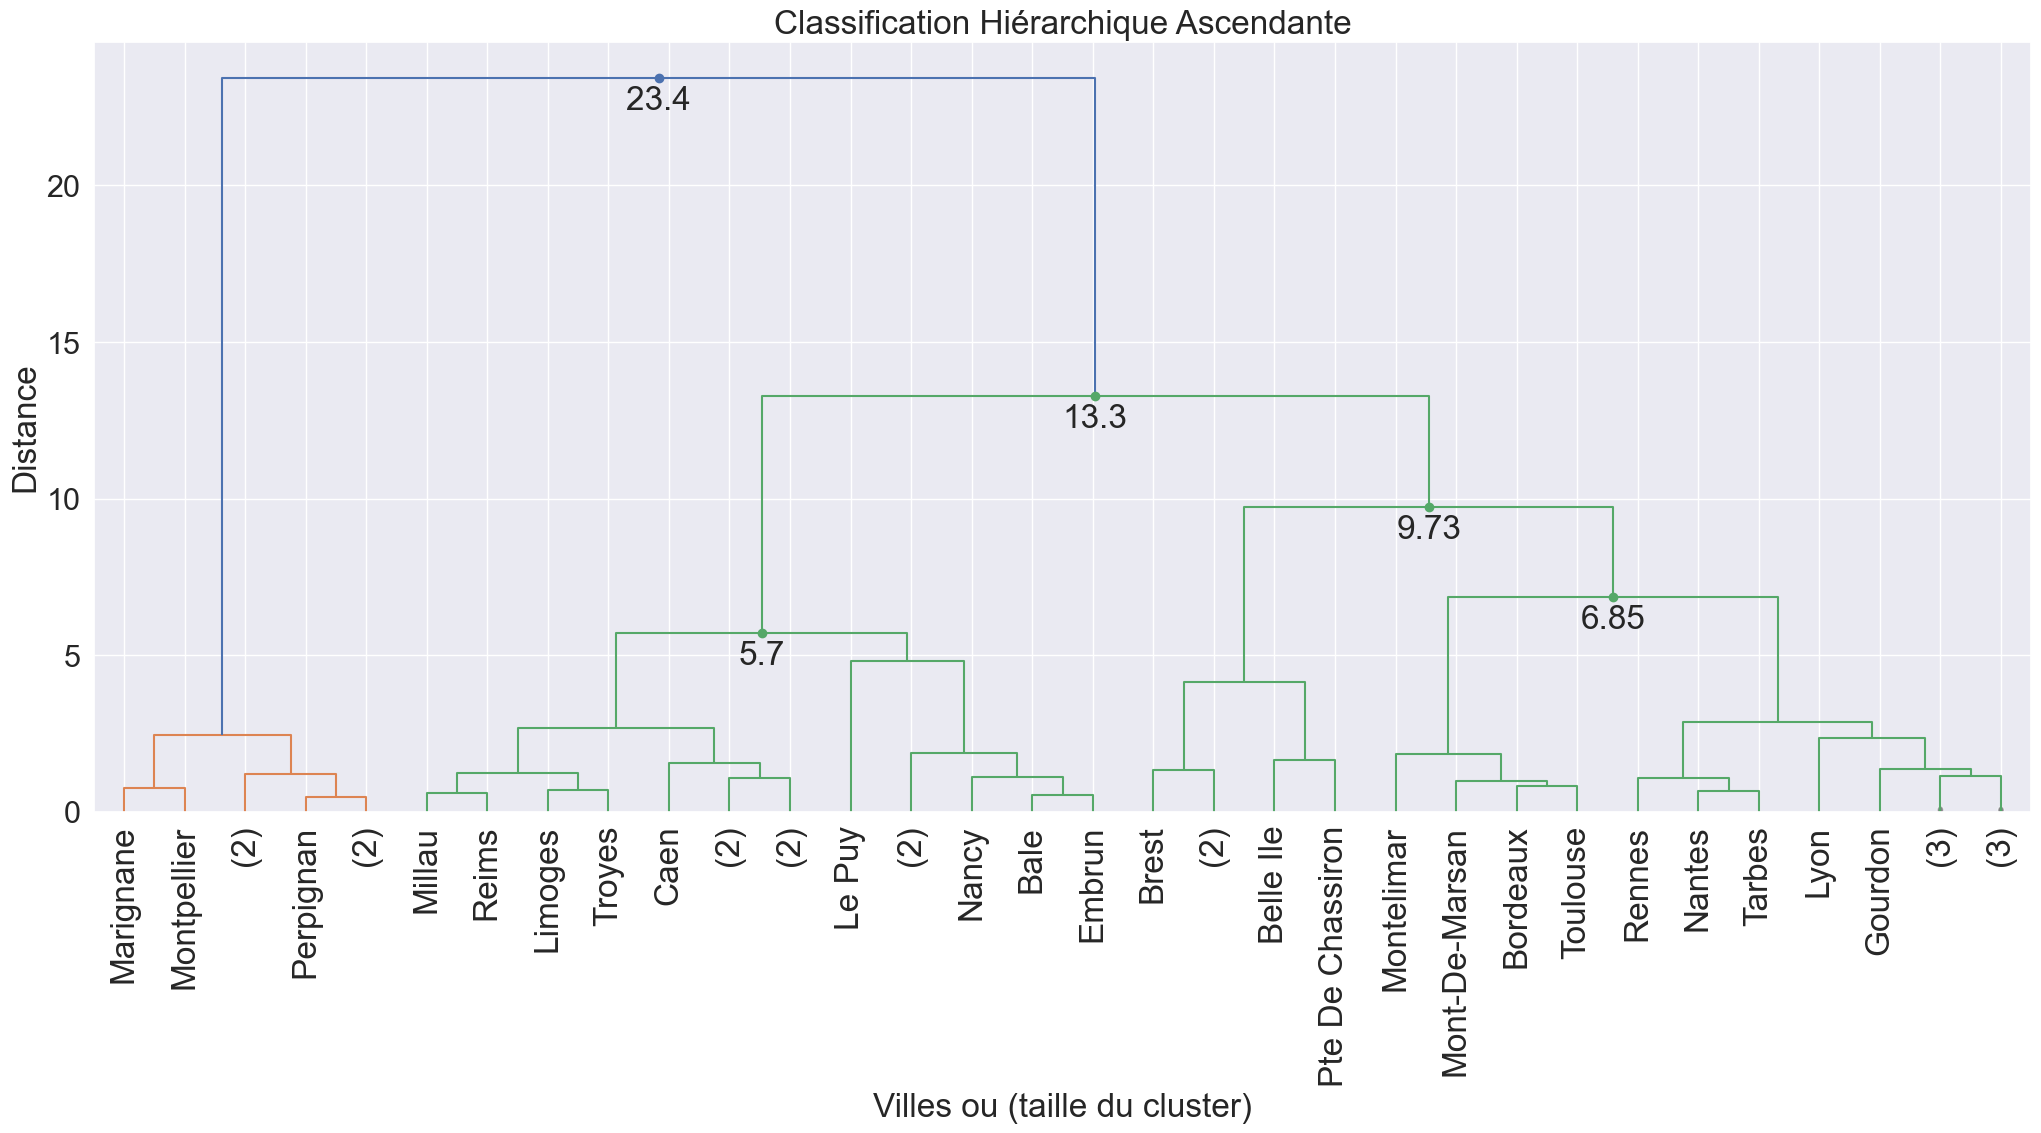

In [28]:
plt.figure(figsize=(25, 10))
afficheDendrogram(
    Z,
    truncate_mode='lastp',
    p=32,                  # nombres des classes
    leaf_rotation=90.,
    leaf_font_size=24.,
    show_contracted=True,
    annotate_above=5,      # les annotations à partir de cette distance
    labels = Villes
)
plt.show()

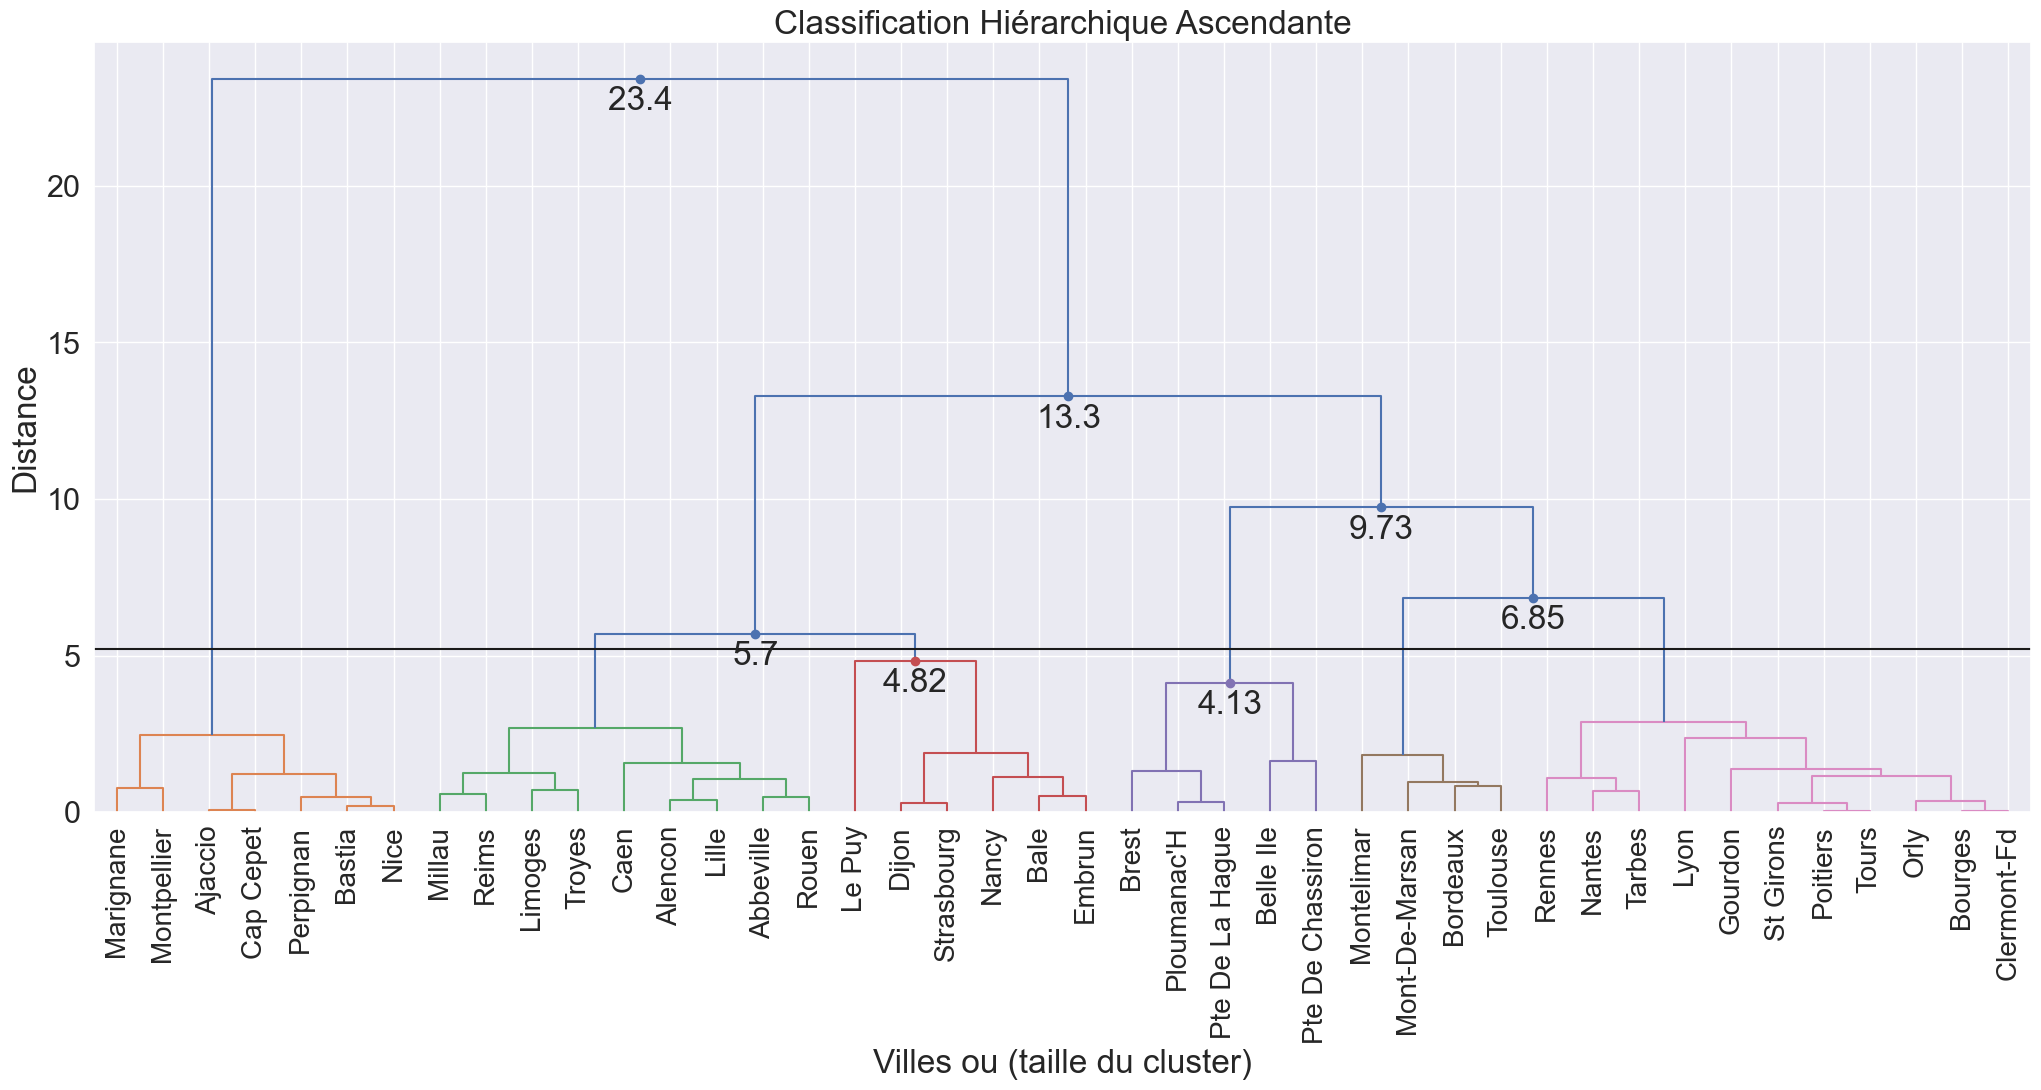

In [29]:
plt.figure(figsize=(25, 10))
afficheDendrogram(
    Z,
    truncate_mode='lastp',
    p=42,                          # nombres des classes
    leaf_rotation=90.,
    leaf_font_size=20.,
    show_contracted=True,
    annotate_above=4,              # les annotations à partir de cette distance
    max_d=5.2,                     # la distance de découpage de l’arbre
    labels = Villes
)
plt.show()

## Prédiction des classes

In [30]:
from scipy.cluster.hierarchy import fcluster
donnees2d['Classe6']=fcluster(Z, t=5, criterion='distance')
donnees2d['Classe4']=fcluster(Z, t=7, criterion='distance')

In [31]:
donnees2d.reset_index()

,Nom,Latitude,Longitude,Altitude,Zone,Dim01,Dim02,Classe6,Classe4
0,Abbeville,50.136000,1.834000,69,NO,2.879743,1.071171,2,2
1,Ajaccio,41.918000,8.792667,5,SE,-5.598592,0.401231,1,1
2,Alencon,48.445500,0.110167,143,NO,2.493413,0.507866,2,2
3,Bale,47.614333,7.510000,263,NE,2.879361,-1.947294,3,2
4,Bastia,42.540667,9.485167,10,SE,-6.167923,0.015735,1,1
5,Belle Ile,47.294333,-3.218333,34,NO,-0.746779,3.057880,4,3
6,Bordeaux,44.830667,-0.691333,47,SO,-2.363250,-0.003414,5,4
7,Bourges,47.059167,2.359833,161,NO,0.862944,-0.822936,6,4
8,Brest,48.444167,-4.412000,94,NO,1.711973,3.166910,4,3
9,Caen,49.180000,-0.456167,67,NO,2.187843,1.711468,2,2


## Affichage des clusters 

In [32]:
fig = px.scatter(donnees2d.reset_index(), 
                    x='Dim01', 
                    y='Dim02', 
                    color='Classe4',
                    text='Nom',
                    size='Classe4',
                    width=1024,
                    height=512,
                    opacity=0.4,
                   )

fig.show()

In [33]:
fig = px.scatter(donnees2d.reset_index(), 
                    x='Dim01', 
                    y='Dim02', 
                    color='Classe6',
                    text='Nom',
                    size='Classe6',
                    width=1024,
                    height=512,
                    opacity=0.4,
                   )

fig.show()

# Clustering non hiérarchique

In [34]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(donnees3d.values)
y_kmeans = kmeans.predict(donnees3d.values)
donnees3d['Km3'] = y_kmeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(donnees3d.values)
y_kmeans = kmeans.predict(donnees3d.values)
donnees3d['Km4'] = y_kmeans

In [35]:
donnees3d.head()

,,,,,Dim01,Dim02,Dim03,Km3,Km4
Nom,Latitude,Longitude,Altitude,Zone,,,,,
Abbeville,50.136000,1.834000,69,NO,2.879743,1.071171,-0.024267,0,2
Ajaccio,41.918000,8.792667,5,SE,-5.598592,0.401231,0.559796,1,0
Alencon,48.445500,0.110167,143,NO,2.493413,0.507866,-0.013326,0,2
Bale,47.614333,7.510000,263,NE,2.879361,-1.947294,-0.157333,0,2
Bastia,42.540667,9.485167,10,SE,-6.167923,0.015735,0.663955,1,0


In [36]:
fig = px.scatter_3d(donnees3d.reset_index(), 
                    x='Dim01', 
                    y='Dim02', 
                    z='Dim03',
                    color='Km3',
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [37]:
fig = px.scatter_3d(donnees3d.reset_index(), 
                    x='Dim01', 
                    y='Dim02', 
                    z='Dim03',
                    color='Km4',
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()